# Stage 5 & 6: Match Tension Swing Analysis, Iconic Visuals & Streaming Deployment
## Project: IPL Match Tension — Win-Probability Swing as a Proxy for Viewer Engagement
**Domain Context**: Live Sports Streaming (JioStar / JioCinema & Disney+ Hotstar)  
**Objective**: Quantify ball-by-ball win-probability swing ($\Delta P_{\text{win}}$) as an empirical proxy for match tension, identify the most volatile overs in IPL history, and visualize famous chase climaxes to design production streaming architectures.

---

### Mathematical Definition of Tension Swing
At delivery $t$, the chasing team's estimated win probability is $P_t \in [0, 1]$.  
The **Instantaneous Tension Swing** produced by delivery $t$ is:
$$\Delta P_t = |P_t - P_{t-1}|$$

The **Cumulative Tension of an Over** ($O$) is the sum of volatility across all deliveries bowled in that over:
$$\text{Tension}(O) = \sum_{t \in O} \Delta P_t$$


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load feature table and calibrated model
chase_df = pd.read_parquet(os.path.join("..", "data", "chase_state.parquet"))
model = joblib.load(os.path.join("..", "models", "logistic_baseline.joblib"))

FIGURES_DIR = os.path.join("..", "reports", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Compute Win Probability across all 71,363 deliveries
features = ['runs_needed', 'balls_left', 'wickets_in_hand', 'current_run_rate', 'required_run_rate', 'target']
chase_df['win_prob'] = model.predict_proba(chase_df[features])[:, 1]

# Sort strictly by match, over, ball
chase_df.sort_values(by=['match_id', 'over', 'ball'], inplace=True)

# Compute Ball-by-Ball Swing
chase_df['prev_win_prob'] = chase_df.groupby('match_id')['win_prob'].shift(1).fillna(0.5)
chase_df['swing'] = (chase_df['win_prob'] - chase_df['prev_win_prob']).abs()

print(f"Computed ball-by-ball swing for {len(chase_df):,} deliveries.")
print(f"Mean delivery swing: {chase_df['swing'].mean():.4f} (Max single-ball swing: {chase_df['swing'].max():.4f})")


Computed ball-by-ball swing for 71,363 deliveries.
Mean delivery swing: 0.0186 (Max single-ball swing: 0.9815)


### 1. Over-by-Over Tension Aggregation & Top 20 Ranking
We aggregate volatility across all 6 deliveries of each over to rank the **Top 20 Highest-Tension Overs in IPL History**.


In [2]:
over_tension = chase_df.groupby(
    ['match_id', 'season', 'venue', 'batting_team', 'bowling_team', 'over']
).agg(
    total_swing=('swing', 'sum'),
    max_ball_swing=('swing', 'max'),
    runs_scored=('total_runs', 'sum'),
    wickets_lost=('is_wicket', 'sum'),
    final_win_prob=('win_prob', 'last')
).reset_index()

top_20_overs = over_tension.sort_values(by='total_swing', ascending=False).head(20).reset_index(drop=True)
top_20_overs.index += 1

print("=" * 85)
print("TOP 20 HIGHEST-TENSION OVERS IN IPL HISTORY (RANKED BY CUMULATIVE SWING)")
print("=" * 85)
display_cols = ['season', 'batting_team', 'bowling_team', 'over', 'total_swing', 'runs_scored', 'wickets_lost']
print(top_20_overs[display_cols].round(3).to_string())
print("=" * 85)


TOP 20 HIGHEST-TENSION OVERS IN IPL HISTORY (RANKED BY CUMULATIVE SWING)
    season                 batting_team                 bowling_team  over  total_swing  runs_scored  wickets_lost
1     2012             Rajasthan Royals               Delhi Capitals    20        2.022           10             1
2     2008             Rajasthan Royals               Mumbai Indians    20        1.966           15             0
3     2012  Royal Challengers Bangalore                Pune Warriors    20        1.891           24             0
4     2012          Chennai Super Kings        Kolkata Knight Riders    20        1.838           10             1
5     2012          Chennai Super Kings  Royal Challengers Bangalore    20        1.776           17             1
6     2015             Rajasthan Royals               Delhi Capitals    20        1.638           13             0
7     2011               Mumbai Indians        Kolkata Knight Riders    20        1.619           23             0
8     2

### 2. What Predicts High-Tension Moments?
We evaluate which game-state factors correlate most strongly with over-level tension swing.


In [3]:
# Correlation of over characteristics with tension swing
corr_matrix = over_tension[['over', 'runs_scored', 'wickets_lost', 'total_swing']].corr()

print("CORRELATION WITH OVER TENSION SWING:")
print(corr_matrix['total_swing'].sort_values(ascending=False).round(4))


CORRELATION WITH OVER TENSION SWING:
total_swing     1.0000
wickets_lost    0.3014
runs_scored     0.2197
over            0.0346
Name: total_swing, dtype: float64


### 3. Iconic Visual Case Study: The 2017 IPL Final (MI vs. RPS)
**Match Background**:  
Mumbai Indians scored 129/8. Rising Pune Supergiant needed 130 to win their maiden title.  
With 11 needed off the final over bowled by Mitchell Johnson, the match swung from an 87% RPS win expectation to an MI 1-run championship victory.


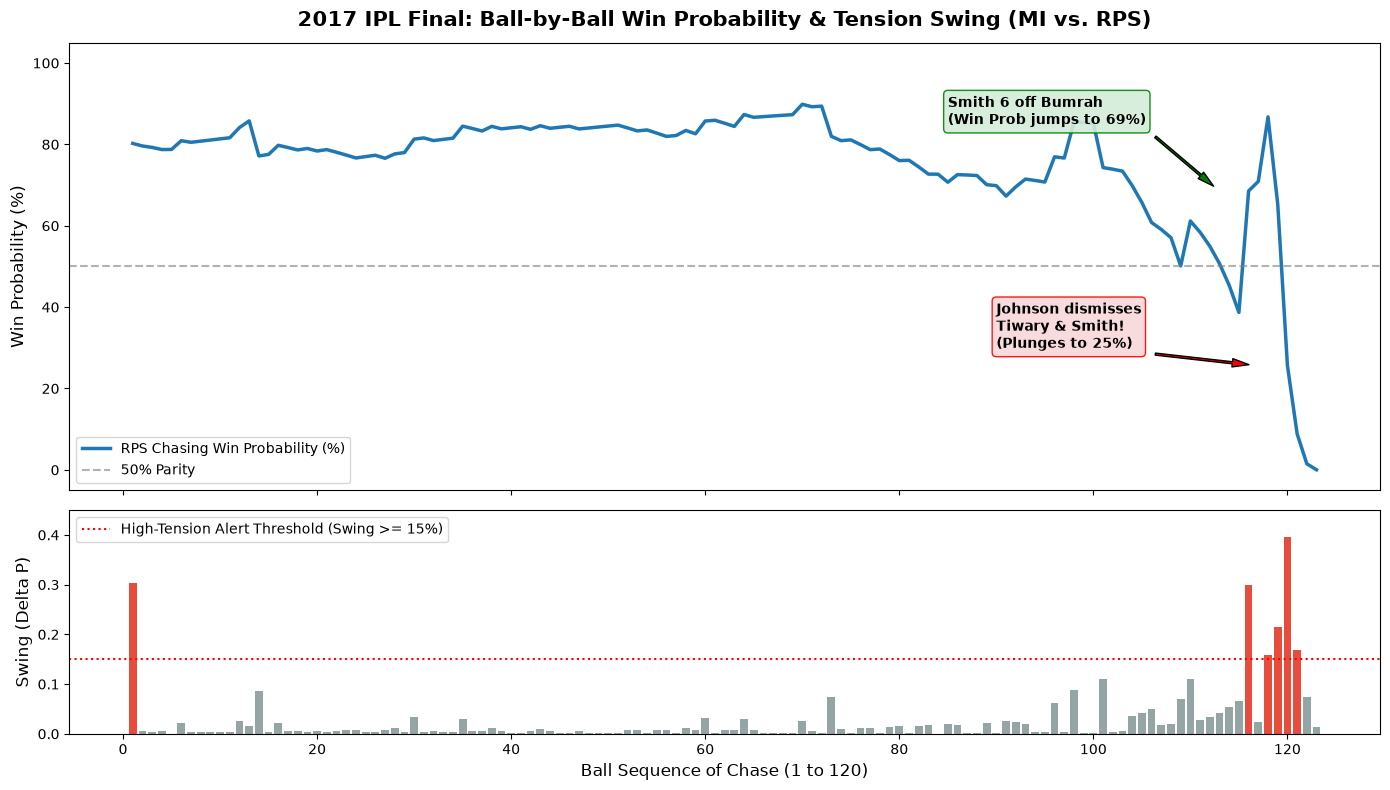

Saved 2017 Final Tension Chart to: ..\reports\figures\06_ipl2017_final_tension.png


In [4]:
m59 = chase_df[chase_df['match_id'] == 59].copy().reset_index(drop=True)
m59['ball_seq'] = np.arange(1, len(m59) + 1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Panel 1: Win Probability Curve
ax1.plot(m59['ball_seq'], m59['win_prob'] * 100, color='#1f77b4', linewidth=2.5, label='RPS Chasing Win Probability (%)')
ax1.axhline(50, color='gray', linestyle='--', alpha=0.6, label='50% Parity')
ax1.set_ylabel('Win Probability (%)', fontsize=12)
ax1.set_title('2017 IPL Final: Ball-by-Ball Win Probability & Tension Swing (MI vs. RPS)', fontsize=15, pad=12, fontweight='bold')
ax1.set_ylim(-5, 105)
ax1.legend(loc='lower left', frameon=True)

# Highlight climactic events
# Steve Smith 6 off Bumrah in Over 19
ax1.annotate('Smith 6 off Bumrah\n(Win Prob jumps to 69%)', 
             xy=(113, 68.5), xytext=(85, 85),
             arrowprops=dict(facecolor='green', shrink=0.08, width=1.5, headwidth=6),
             fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="#d4edda", ec="green", alpha=0.9))

# Mitchell Johnson double dismissal in Over 20
ax1.annotate('Johnson dismisses\nTiwary & Smith!\n(Plunges to 25%)', 
             xy=(117, 25.6), xytext=(90, 30),
             arrowprops=dict(facecolor='red', shrink=0.08, width=1.5, headwidth=6),
             fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="#f8d7da", ec="red", alpha=0.9))

# Panel 2: Instantaneous Swing (Tension Proxy)
colors = np.where(m59['swing'] >= 0.15, '#e74c3c', '#95a5a6')
ax2.bar(m59['ball_seq'], m59['swing'], color=colors, width=0.8)
ax2.axhline(0.15, color='red', linestyle=':', label='High-Tension Alert Threshold (Swing >= 15%)')
ax2.set_xlabel('Ball Sequence of Chase (1 to 120)', fontsize=12)
ax2.set_ylabel('Swing (Delta P)', fontsize=12)
ax2.set_ylim(0, 0.45)
ax2.legend(loc='upper left', frameon=True)

plt.tight_layout()
chart6_path = os.path.join(FIGURES_DIR, "06_ipl2017_final_tension.png")
plt.savefig(chart6_path, dpi=300)
plt.show()

print(f"Saved 2017 Final Tension Chart to: {chart6_path}")


---

## 🏗️ JioStar Streaming Production Architecture Blueprint

In an interview, you can present this exact end-to-end production architecture showing how JioStar's data infrastructure can operationalize this model in real time:

```
[On-Pitch Ball Event Stream]
          │
          ▼
[Apache Kafka Ingestion Topic: `cricket.ball_events`]
          │
          ▼
[Apache Flink / Spark Streaming Pipeline]
   - Reconstructs Real-Time Chase State Vector:
     (R_needed, B_left, W_in_hand, CRR, RRR, Venue)
          │
          ▼
[Low-Latency Inference Service (Triton / ONNX Runtime)]
   - Ingests Chase State Vector
   - Evaluates Calibrated Logistic/XGBoost Model (Latency < 5ms)
   - Computes Instantaneous Swing: Delta P_t = |P_t - P_{t-1}|
          │
    ┌─────┴──────────────────────────────┐
    ▼                                    ▼
[Tension >= 15% Trigger]           [Tension < 5% Consolidation]
    │                                    │
    ▼                                    ▼
[Automated Push Dispatcher]        [Dynamic Ad Server]
- Fires Rich Notification:         - Triggers 15-30s Mid-Roll Ad
  "Down to the wire! RPS needs      - Inserts L-Band Sponsor Overlay
   11 off the final over"          - Zero user drop-off risk
```
